# M6-B1 — Analyse de dérive

## 1. Exploration — distributions référence vs prod

In [1]:
# On charge les deux jeux de données
import pandas as pd
import matplotlib.pyplot as plt

ref = pd.read_csv("../data/reference_set.csv")   # données d'entraînement
prod = pd.read_csv("../data/prod_3months.csv")   # données de production

print("Référence :", ref.shape)
print("Production :", prod.shape)
ref.head()

Référence : (1500, 15)
Production : (3000, 16)


,loan_amnt,term,int_rate,installment,grade,emp_length,home_ownership,annual_inc,verification_status,purpose,dti,delinq_2yrs,fico_range_low,revol_util,loan_status
0,7600,36 months,11.39,250.22,B,3 years,MORTGAGE,72500,Verified,debt_consolidation,13.12,1,725,48.0,Fully Paid
1,12800,60 months,14.74,302.77,C,10+ years,RENT,24500,Not Verified,debt_consolidation,28.10,0,692,50.5,Fully Paid
2,11400,36 months,7.06,352.31,A,3 years,MORTGAGE,112500,Verified,debt_consolidation,22.78,0,747,66.4,Fully Paid
3,40000,36 months,21.11,1509.26,E,8 years,RENT,71300,Verified,debt_consolidation,15.85,0,671,17.6,Fully Paid
4,12600,36 months,9.99,406.51,B,6 years,RENT,63500,Not Verified,debt_consolidation,9.31,1,733,39.0,Fully Paid


In [2]:
# On compte les valeurs manquantes AVANT de tracer quoi que ce soit :
# matplotlib refuse les NaN, et un dropna() silencieux réduirait l'effectif
# sans qu'on s'en rende compte. Un taux de manquants qui diffère entre
# référence et prod est lui-même un signal (ETL cassé, colonne plus alimentée).
num_cols = ["loan_amnt", "int_rate", "installment", "annual_inc",
            "dti", "delinq_2yrs", "fico_range_low", "revol_util"]

missing = pd.DataFrame({
    "n_missing_ref": ref[num_cols].isna().sum(),
    "%_missing_ref": (ref[num_cols].isna().mean() * 100).round(2),
    "n_missing_prod": prod[num_cols].isna().sum(),
    "%_missing_prod": (prod[num_cols].isna().mean() * 100).round(2),
})
missing

,n_missing_ref,%_missing_ref,n_missing_prod,%_missing_prod
loan_amnt,0,0.00,0,0.0
int_rate,0,0.00,0,0.0
installment,0,0.00,0,0.0
annual_inc,0,0.00,0,0.0
dti,0,0.00,0,0.0
delinq_2yrs,0,0.00,0,0.0
fico_range_low,0,0.00,0,0.0
revol_util,20,1.33,36,1.2


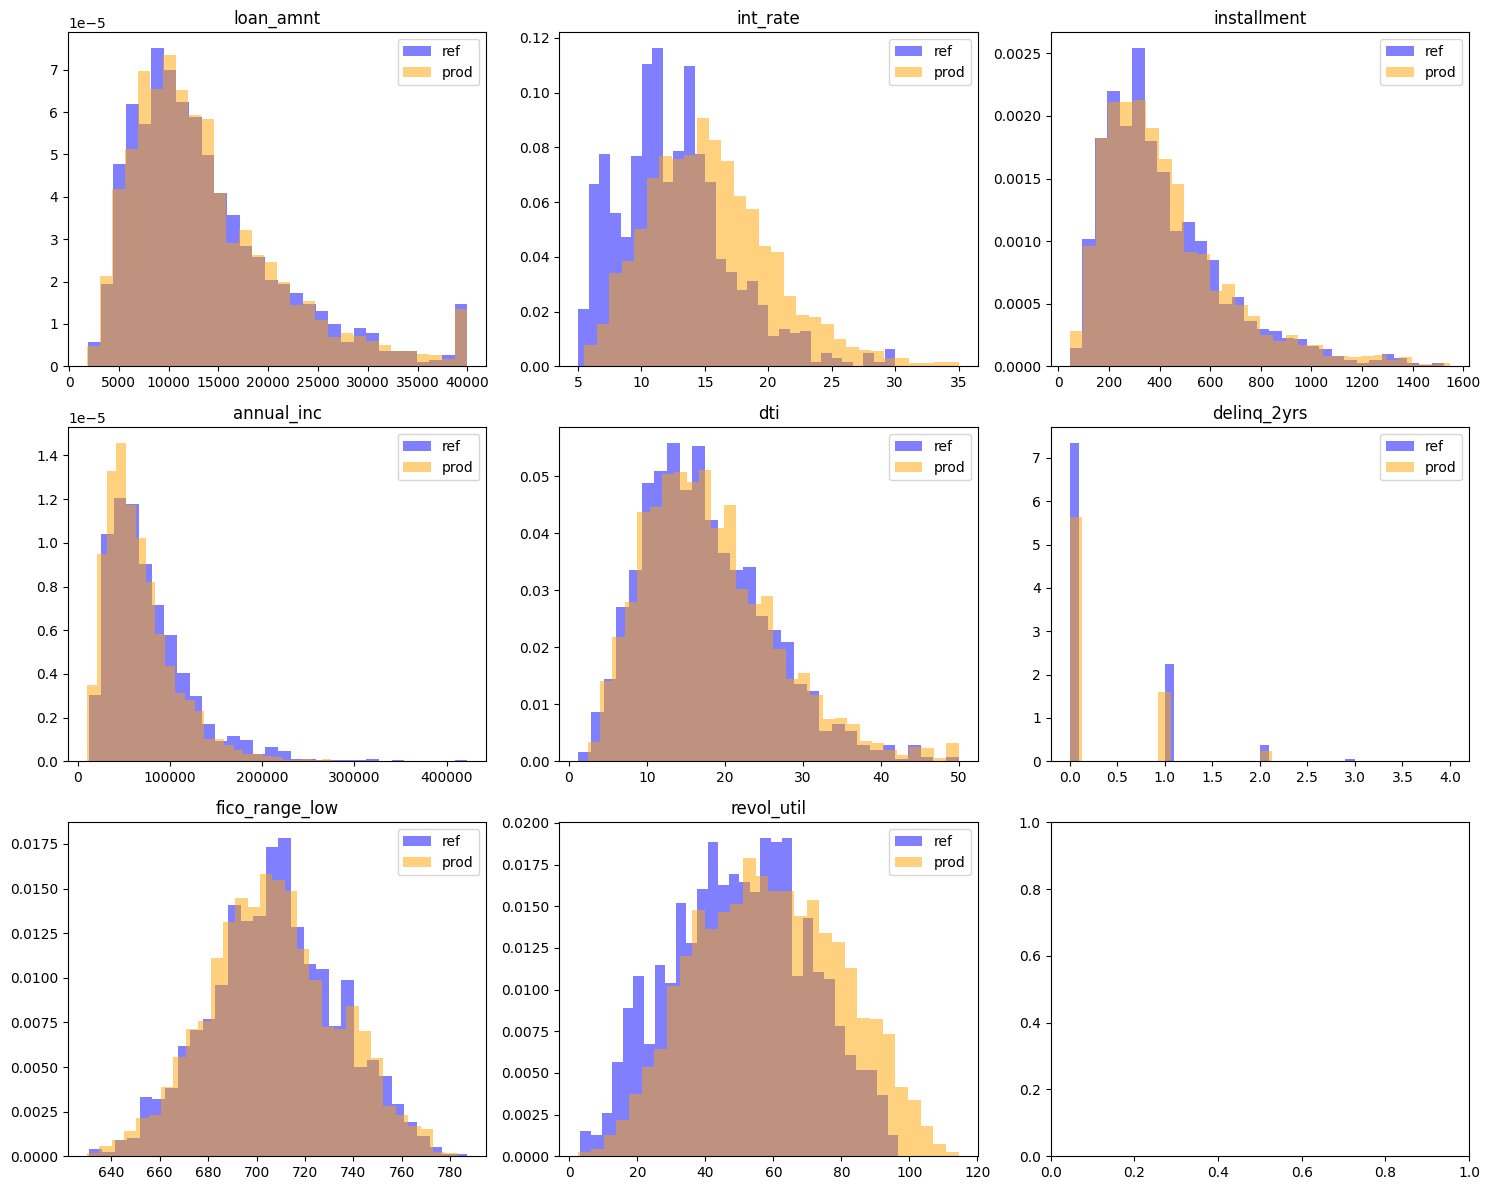

In [3]:
# Variables numériques : on superpose les histogrammes ref vs prod
# pour voir visuellement si les distributions ont bougé
num_cols = ["loan_amnt", "int_rate", "installment", "annual_inc",
            "dti", "delinq_2yrs", "fico_range_low", "revol_util"]

fig, axes = plt.subplots(3, 3, figsize=(15, 12))
axes = axes.flatten()

for i, col in enumerate(num_cols):
    axes[i].hist(ref[col].dropna(), bins=30, alpha=0.5, label="ref", color="blue", density=True)
    axes[i].hist(prod[col].dropna(), bins=30, alpha=0.5, label="prod", color="orange", density=True)
    axes[i].set_title(col)
    axes[i].legend()

plt.tight_layout()
plt.show()

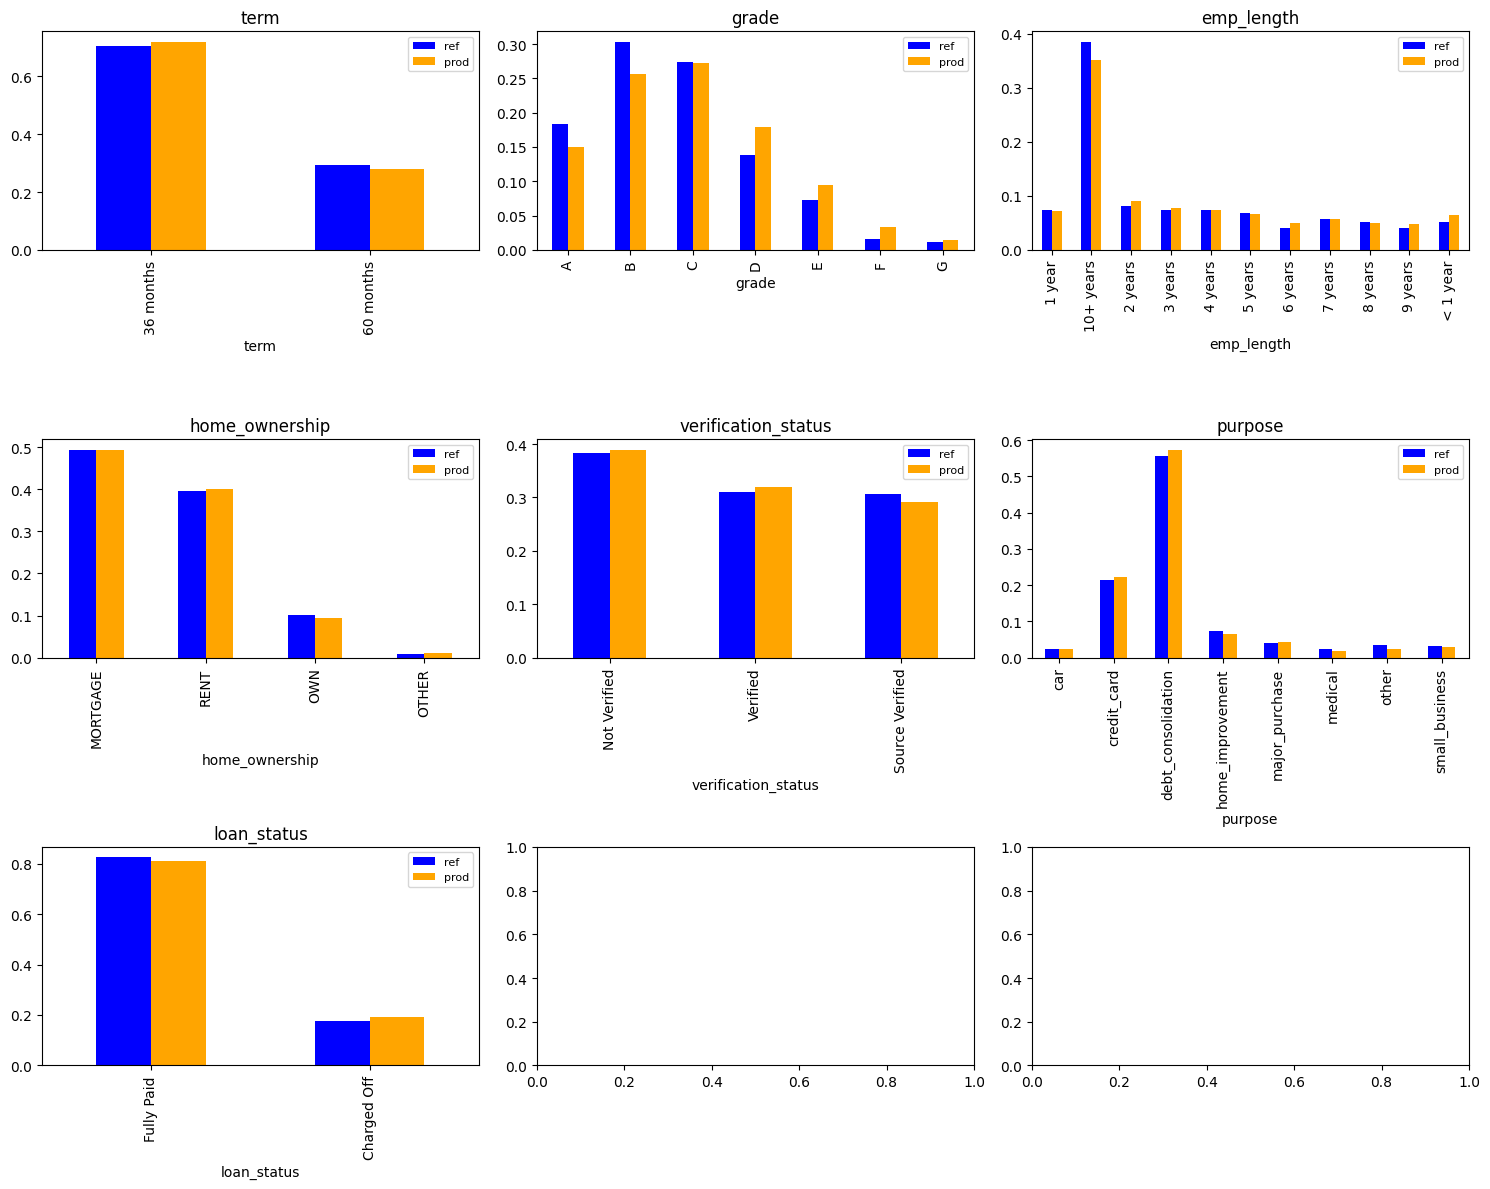

In [4]:
# Variables catégorielles : on compare les proportions de chaque modalité
cat_cols = ["term", "grade", "emp_length", "home_ownership",
            "verification_status", "purpose", "loan_status"]

fig, axes = plt.subplots(3, 3, figsize=(15, 12))
axes = axes.flatten()

for i, col in enumerate(cat_cols):
    ref_freq = ref[col].value_counts(normalize=True)
    prod_freq = prod[col].value_counts(normalize=True)
    df_freq = pd.DataFrame({"ref": ref_freq, "prod": prod_freq}).fillna(0)
    df_freq.plot.bar(ax=axes[i], color=["blue", "orange"])
    axes[i].set_title(col)
    axes[i].legend(fontsize=8)

plt.tight_layout()
plt.show()

### Lecture à l'œil (avant tout calcul)

1. Le taux d'intérêt (`int_rate`) est plus élevé en prod : en moyenne 15,50 %
   contre 12,61 % dans la référence, soit +2,9 points. C'est le décalage le
   plus net de toutes les variables — celui qu'on voit tout de suite sur le
   graphique.
2. La note de risque du dossier (`grade`) s'est dégradée : il y a moins de
   bons dossiers (note A, B) et plus de dossiers risqués (note D, E, F) en
   prod qu'avant. Logique : c'est justement cette note qui détermine le taux
   d'intérêt, donc ces deux changements racontent probablement la même
   chose — un seul phénomène (le mix de clients qui arrive a changé), pas
   deux problèmes séparés.
3. Le revenu annuel (`annual_inc`) a baissé d'environ 13 % en moyenne : les
   emprunteurs actuels gagnent moins que ceux de la référence.
4. Le taux d'utilisation du crédit renouvelable (`revol_util`) a augmenté
   (50,6 → 59,0). Sur les manquants : les deux jeux en ont (20/1500 = 1,33 %
   en référence, 36/3000 = 1,2 % en prod) — le taux est stable entre les
   deux, donc ce n'est pas un signal ETL en soi, juste une colonne
   partiellement incomplète dans les deux populations.
5. Le taux de défaut réel (la vraie proportion de mauvais payeurs) est passé
   de 17,5 % à 19,1 % — une hausse légère de 1,6 point, cohérente avec
   l'arrivée de dossiers plus risqués.

Ce qui n'a pas bougé : le montant emprunté, la mensualité, le taux
d'endettement, l'historique d'incidents de paiement, la durée du prêt,
l'ancienneté professionnelle, le type de logement, le mode de vérification,
le motif du prêt. Ces variables ont l'air stables, et aucune n'a de
manquants dans ni l'un ni l'autre jeu.

→ À confirmer statistiquement en section 2 : `int_rate`, `grade`,
`annual_inc` sont les features à surveiller en priorité. `revol_util` reste
à regarder (moyenne en hausse) mais son taux de manquants n'est plus un
signal d'alerte une fois compté correctement.


## 2. Détection statistique — PSI · KS · Chi²

In [5]:
# TODO


## 3. Calibration en exploitation

In [6]:
# TODO


## 4. Performance dans le temps

In [7]:
# TODO


## 5. Diagnostic & recommandation

In [8]:
# TODO
